# Risco de acidentes com lógica Fuzzy

## Problemática
Apesar das recomendações realizadas em campanhas de conscientização por orgãos federais e estaduais, a quantidade de acidentes que ocorrem no trânsito no Brasil e no mundo continua com número elevados a cada ano em rodovias. 

Com os avanços da tecnologia em veículos, é possivel não depender somente da atenção do motorista mas também alertá-lo durante o trajeto da possibilidade de um acidente ocorrer auxiliando em tomadas de decisões mais seguras evitando fatalidades durante o trajeto.

## Objetivo e justificativa
Desenvolver um sistema baseado em lógica fuzzy capaz avaliar o risco de acidentes com base em fatores relacionados à condução, como velocidade, condição da pista e visibilidade.

A utilização da Lógica Fuzzy para este sistema permite representar conceitos subjetivos presentes no cotidiano pois trabalha com incertezas com graus de pertinência aproximando-se do raciocínio humano. No porblema em questão, situações como "velocidade alta", "pista em boas condições", dentre outros não possue limites rígidos. Por meio de tais regras, é possível combinar as informações e produzir uma estimativa de risco de acidentes auxiliando na prevenção.



### Passo 0: Setup da aplicação

In [11]:
!pip install scikit-fuzzy networkx numpy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

### Passo 1: Definição de variáveis (conjuntos fuzzy)

Entradas:
* *Velocidade:* (0 a 120km/h)
*  *Pista* (0% a 100%)
* *Visibilidade:* (0 a 500 metros)
  
Saída:
 *  *Risco:* (0 a 10)


In [12]:
vel= ctrl.Antecedent(np.arange(0, 121, 1), 'velocidade')
pista = ctrl.Antecedent(np.arange(0, 100, 1), 'pista')
vsb = ctrl.Antecedent(np.arange(0, 501, 1), 'visibilidade')
risco = ctrl.Consequent(np.arange(0, 11, 1), 'risco')

### Passo 2: Definição das funções de pertinência 

1. Velocidade
   * Pontos de velocidade constante, ponto de equilíbro e com sobreposições
2. Pista
   * Zonas com transição de ocupação de veículos na pista
3. Visibilidade
   * Análise das condições ruim, moderadas ou boas para o motorista
4. Risco
   * Cada nível com máxima representatividade

As sobreposições permitem uma situação realista do trânsito

In [13]:

vel['baixa'] = fuzz.trapmf(vel.universe, [0, 0, 20, 40]) 
vel['media'] = fuzz.trimf(vel.universe, [30, 50, 70])
vel['alta'] = fuzz.trapmf(vel.universe, [60, 80, 120, 120])

pista['livre'] = fuzz.trapmf(pista.universe, [0, 0, 20, 30])
pista['moderada'] = fuzz.trimf(pista.universe, [20, 45, 70])
pista['congestionada'] = fuzz.trapmf(pista.universe, [60, 80, 100, 100])

vsb['baixa'] = fuzz.trapmf(vsb.universe, [0, 0, 30, 50])
vsb['media'] = fuzz.trimf(vsb.universe, [40, 100, 200])
vsb['alta'] = fuzz.trapmf(vsb.universe, [150, 300, 500, 500])

risco['baixo'] = fuzz.trimf(risco.universe, [0, 0, 5])
risco['medio'] = fuzz.trimf(risco.universe, [3, 5, 8])
risco['alto'] = fuzz.trimf(risco.universe, [6, 10, 10])

### Passo 3 – Visualizar funções

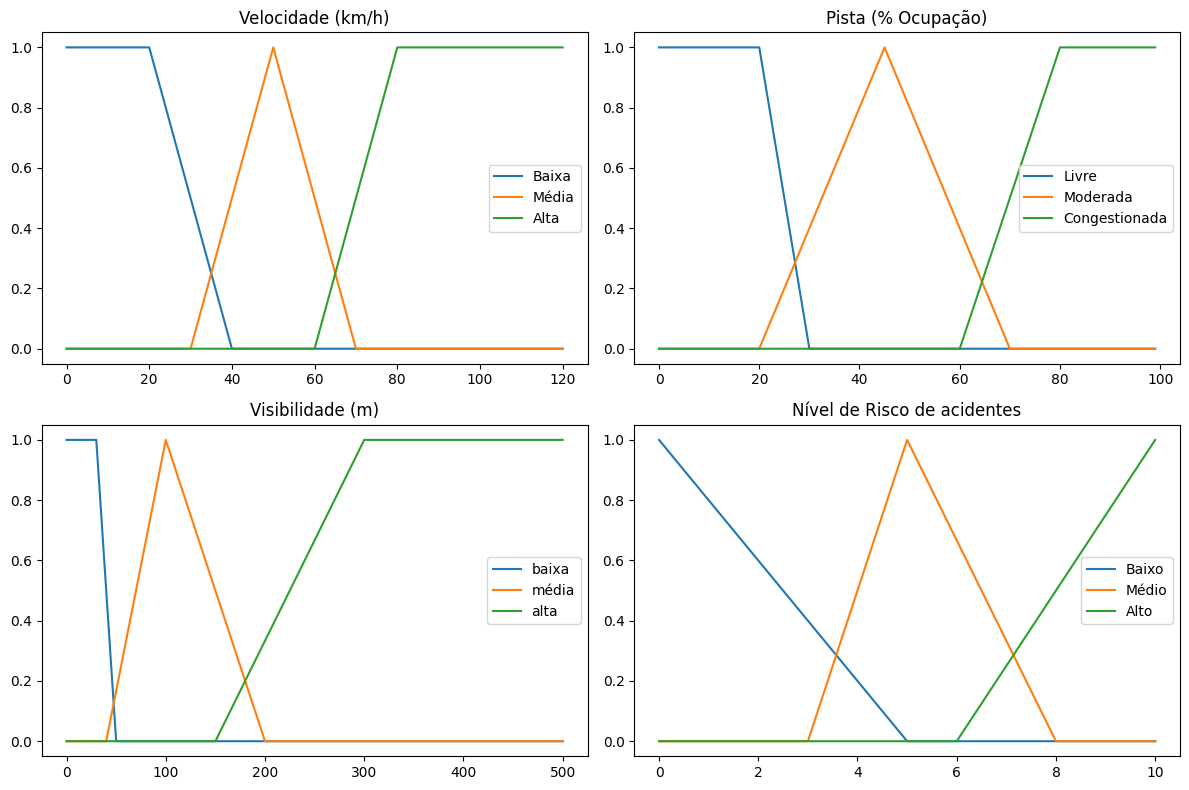

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
# Velocidade
axs[0, 0].plot(vel.universe, vel['baixa'].mf, label='Baixa')
axs[0, 0].plot(vel.universe, vel['media'].mf, label='Média')
axs[0, 0].plot(vel.universe, vel['alta'].mf, label='Alta')
axs[0, 0].set_title('Velocidade (km/h)')
axs[0, 0].legend()

# Pista
axs[0, 1].plot(pista.universe, pista['livre'].mf, label='Livre')
axs[0, 1].plot(pista.universe, pista['moderada'].mf, label='Moderada')
axs[0, 1].plot(pista.universe, pista['congestionada'].mf, label='Congestionada')
axs[0, 1].set_title('Pista (% Ocupação)')
axs[0, 1].legend()

# Visibilidade
axs[1, 0].plot(vsb.universe, vsb['baixa'].mf, label='baixa')
axs[1, 0].plot(vsb.universe, vsb['media'].mf, label='média')
axs[1, 0].plot(vsb.universe, vsb['alta'].mf, label='alta')
axs[1, 0].set_title('Visibilidade (m)')
axs[1, 0].legend()

# Risco
axs[1, 1].plot(risco.universe, risco['baixo'].mf, label='Baixo')
axs[1, 1].plot(risco.universe, risco['medio'].mf, label='Médio')
axs[1, 1].plot(risco.universe, risco['alto'].mf, label='Alto')
axs[1, 1].set_title('Nível de Risco de acidentes')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


### Passo 4 – Definir Regras Fuzzy (SE … ENTÃO)

As regras combinam os conjuntos fuzzy das variáveis de entrada para determinar o nível de risco.
Cada regra segue a lógica **SE condição ENTÃO consequência**, representando situações reais do trânsito.

In [ ]:
# SE velocidade baixa E pista livre E visibilidade alta ENTÃO risco baixo
rule1 = ctrl.Rule(vel['baixa'] & pista['livre'] & vsb['alta'], risco['baixo'])

# SE velocidade media E pista moderada E visibilidade media ENTÃO risco medio
rule2 = ctrl.Rule(vel['media'] & pista['moderada'] & vsb['media'], risco['medio'])

# SE velocidade alta E pista congestionada E visibilidade baixa ENTÃO risco alto
rule3 = ctrl.Rule(vel['alta'] & pista['congestionada'] & vsb['baixa'], risco['alto'])

# SE velocidade alta E visibilidade baixa ENTÃO risco alto
rule4 = ctrl.Rule(vel['alta'] & vsb['baixa'], risco['alto'])

# SE velocidade baixa E visibilidade alta ENTÃO risco baixo
rule5 = ctrl.Rule(vel['baixa'] & vsb['alta'], risco['baixo'])

# SE velocidade alta E pista livre ENTÃO risco medio
rule6 = ctrl.Rule(vel['alta'] & pista['livre'], risco['medio'])

# SE pista congestionada E visibilidade baixa ENTÃO risco alto
rule7 = ctrl.Rule(pista['congestionada'] & vsb['baixa'], risco['alto'])

# SE velocidade media E pista livre E visibilidade alta ENTÃO risco baixo
rule8 = ctrl.Rule(vel['media'] & pista['livre'] & vsb['alta'], risco['baixo'])

# SE velocidade alta E pista moderada E visibilidade media ENTÃO risco alto
rule9 = ctrl.Rule(vel['alta'] & pista['moderada'] & vsb['media'], risco['alto'])

# SE velocidade baixa E pista congestionada E visibilidade media ENTÃO risco medio
rule10 = ctrl.Rule(vel['baixa'] & pista['congestionada'] & vsb['media'], risco['medio'])

# SE velocidade media E pista congestionada E visibilidade media ENTÃO risco alto
rule11 = ctrl.Rule(vel['media'] & pista['congestionada'] & vsb['media'], risco['alto'])

# SE velocidade alta E pista moderada E visibilidade alta ENTÃO risco medio
rule12 = ctrl.Rule(vel['alta'] & pista['moderada'] & vsb['alta'], risco['medio'])

# Construir o sistema de controle fuzzy
rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12]
risco_ctrl = ctrl.ControlSystem(rules)
risco_sim = ctrl.ControlSystemSimulation(risco_ctrl)

print('Sistema fuzzy criado com', len(rules), 'regras.')

### Passo 5 – Defuzzificação (método centroid)

A defuzzificação transforma o conjunto fuzzy de saída em um valor numérico preciso.
Utilizamos o método **centroid** (centro de gravidade), que calcula o ponto médio ponderado
da área sob a curva de saída — o mais comum no método Mamdani.

In [ ]:
def compute_risk(velocidade, pista_val, visibilidade):
    """
    Calcula o nível de risco de acidente usando inferência fuzzy Mamdani
    com defuzzificação pelo método centroid.

    Parâmetros:
        velocidade   : float — velocidade do veículo em km/h (0 a 120)
        pista_val    : float — ocupação da pista em % (0 a 99)
        visibilidade : float — visibilidade em metros (0 a 500)

    Retorna:
        float — nível de risco calculado (0 a 10)
    """
    risco_sim.input['velocidade'] = velocidade
    risco_sim.input['pista'] = pista_val
    risco_sim.input['visibilidade'] = visibilidade
    risco_sim.compute()  # método de defuzzificação padrão: centroid
    return risco_sim.output['risco']

# Exemplo rápido
exemplo = compute_risk(velocidade=80, pista_val=30, visibilidade=100)
print(f'Exemplo — velocidade=80, pista=30%, visibilidade=100m → risco={exemplo:.2f}')

### Passo 6 – Cenários de Teste (inline)

Definimos cenários representativos com valores de entrada e o resultado esperado.
Cada cenário descreve uma situação real do trânsito:

| Cenário | Situação |
|---------|----------|
| 1 | Estrada vazia, boa visibilidade, velocidade moderada — risco baixo |
| 2 | Alta velocidade, pista congestionada, visibilidade baixa — risco alto |
| 3 | Situação intermediária com velocidade média — risco médio |
| 4 | Pista livre mas velocidade muito alta — risco médio |
| 5 | Congestionamento com baixa visibilidade e velocidade baixa — risco médio/alto |

In [ ]:
scenarios = [
    {
        'name': 'Cenário 1 — Velocidade Baixa, Pista Livre, Visibilidade Alta (Risco Baixo)',
        'descricao': 'Estrada livre, boa visibilidade, velocidade baixa',
        'inputs': {'velocidade': 20, 'pista_val': 10, 'visibilidade': 400},
        'expected': 1.67
    },
    {
        'name': 'Cenário 2 — Velocidade Alta, Congestionamento, Nublado (Risco Alto)',
        'descricao': 'Alta velocidade, pista congestionada, baixa visibilidade',
        'inputs': {'velocidade': 100, 'pista_val': 85, 'visibilidade': 20},
        'expected': 8.67
    },
    {
        'name': 'Cenário 3 — Velocidade Mèdia, Congestionamento Médio, Visibilidade Média (Risco Médio)',
        'descricao': 'Velocidade e ocupação moderadas, visibilidade média',
        'inputs': {'velocidade': 50, 'pista_val': 45, 'visibilidade': 100},
        'expected': 5.33
    },
    {
        'name': 'Cenário 4 — Velocidade Alta, Pista Livre',
        'descricao': 'Alta velocidade mas pista livre e boa visibilidade',
        'inputs': {'velocidade': 90, 'pista_val': 15, 'visibilidade': 350},
        'expected': 5.33
    },
    {
        'name': 'Cenário 5 — Congestionamento com Neblina',
        'descricao': 'Pista congestionada e visibilidade muito baixa, velocidade baixa',
        'inputs': {'velocidade': 25, 'pista_val': 80, 'visibilidade': 15},
        'expected': 8.67
    },
]

print(f'{len(scenarios)} cenários de teste carregados.')

### Passo 7 – Validação dos Cenários

Para cada cenário, calculamos o risco inferido e comparamos com o valor esperado.
Um cenário é **aprovado** (✅) se o erro percentual for ≤ 5 %. Caso contrário, é **reprovado** (❌).

In [ ]:
TOLERANCIA = 0.05  # 5%

# Encontra a largura máxima para alinhar as colunas perfeitamente
max_name_len = max(len(s['name']) for s in scenarios)
col_name_width = max(max_name_len, 10)

# Cabeçalho da Tabela com caracteres de caixa (box-drawing)
header = f"│ {'Cenário':<{col_name_width}} │ {'Entradas (Vel / Pista / Vis)':^30} │ {'Predito':^9} │ {'Esperado':^9} │ {'Erro %':^8} │ {'Status':^6} │"
sep_top  = f"┌─{'─'*col_name_width}─┬─{'─'*30}─┬─{'─'*9}─┬─{'─'*9}─┬─{'─'*8}─┬─{'─'*6}─┐"
sep_mid  = f"├─{'─'*col_name_width}─┼─{'─'*30}─┼─{'─'*9}─┼─{'─'*9}─┼─{'─'*8}─┼─{'─'*6}─┤"
sep_bot  = f"└─{'─'*col_name_width}─┴─{'─'*30}─┴─{'─'*9}─┴─{'─'*9}─┴─{'─'*8}─┴─{'─'*6}─┘"

print(sep_top)
print(header)
print(sep_mid)

todos_aprovados = True
resultados = []

for s in scenarios:
    predito = compute_risk(**s['inputs'])
    esperado = s['expected']
    # Erro percentual relativo ao valor esperado
    erro = abs(predito - esperado) / esperado
    status = '✅' if erro <= TOLERANCIA else '❌'
    if erro > TOLERANCIA:
        todos_aprovados = False
    resultados.append({'name': s['name'], 'predito': predito, 'esperado': esperado,
                        'erro': erro, 'status': status})
    
    # Formata entradas de forma compacta
    inputs_str = f"Vel: {s['inputs']['velocidade']} | Pist: {s['inputs']['pista_val']}% | Vis: {s['inputs']['visibilidade']}m"
    
    print(f"│ {s['name']:<{col_name_width}} │ {inputs_str:^30} │ {predito:>9.2f} │ {esperado:>9.2f} │ {erro*100:>7.1f}% │ {status:^6} │")

print(sep_bot)
print()

if todos_aprovados:
    print('✅ Todos os cenários aprovados dentro da tolerância de 5%.')
else:
    print('⚠️ Alguns cenários ultrapassaram a tolerância de 5%.')
    print('   Considere ajustar as regras fuzzy ou os valores esperados.')

### Passo 8 – Visualização Completa

Geramos um gráfico que combina:
- As **funções de pertinência** das entradas e da saída
- Os **pontos de risco** calculados para cada cenário de teste

A figura é salva em `docs/resultado.png`.

In [ ]:
import os

os.makedirs('docs', exist_ok=True)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Sistema Fuzzy — Risco de Acidentes (Validação)', fontsize=14, fontweight='bold')

# --- Funções de pertinência ---
axs[0, 0].plot(vel.universe, vel['baixa'].mf, label='Baixa')
axs[0, 0].plot(vel.universe, vel['media'].mf, label='Média')
axs[0, 0].plot(vel.universe, vel['alta'].mf, label='Alta')
axs[0, 0].set_title('Velocidade (km/h)')
axs[0, 0].legend()

axs[0, 1].plot(pista.universe, pista['livre'].mf, label='Livre')
axs[0, 1].plot(pista.universe, pista['moderada'].mf, label='Moderada')
axs[0, 1].plot(pista.universe, pista['congestionada'].mf, label='Congestionada')
axs[0, 1].set_title('Pista (% Ocupação)')
axs[0, 1].legend()

axs[1, 0].plot(vsb.universe, vsb['baixa'].mf, label='Baixa')
axs[1, 0].plot(vsb.universe, vsb['media'].mf, label='Média')
axs[1, 0].plot(vsb.universe, vsb['alta'].mf, label='Alta')
axs[1, 0].set_title('Visibilidade (m)')
axs[1, 0].legend()

axs[1, 1].plot(risco.universe, risco['baixo'].mf, label='Baixo')
axs[1, 1].plot(risco.universe, risco['medio'].mf, label='Médio')
axs[1, 1].plot(risco.universe, risco['alto'].mf, label='Alto')
axs[1, 1].set_title('Nível de Risco')
axs[1, 1].legend()

# --- Gráfico de validação ---
nomes  = [r['name'].split('—')[0].strip() for r in resultados]
pred   = [r['predito']  for r in resultados]
esp    = [r['esperado'] for r in resultados]
cores  = ['green' if r['status'] == '✅' else 'red' for r in resultados]

x = range(len(nomes))
axs[0, 2].bar([i - 0.2 for i in x], pred, 0.4, label='Predito', color='steelblue')
axs[0, 2].bar([i + 0.2 for i in x], esp,  0.4, label='Esperado', color='orange')
axs[0, 2].set_xticks(list(x))
axs[0, 2].set_xticklabels(nomes, rotation=15, ha='right', fontsize=8)
axs[0, 2].set_ylim(0, 11)
axs[0, 2].set_ylabel('Risco (0-10)')
axs[0, 2].set_title('Predito vs Esperado')
axs[0, 2].legend()

# --- Gráfico de erro percentual ---
erros_pct = [r['erro'] * 100 for r in resultados]
bar_colors = ['green' if e <= 5 else 'red' for e in erros_pct]
axs[1, 2].bar(nomes, erros_pct, color=bar_colors)
axs[1, 2].axhline(5, color='black', linestyle='--', linewidth=1, label='Tolerância 5%')
axs[1, 2].set_xticklabels(nomes, rotation=15, ha='right', fontsize=8)
axs[1, 2].set_ylabel('Erro (%)')
axs[1, 2].set_title('Erro Percentual por Cenário')
axs[1, 2].legend()

plt.tight_layout()
plt.savefig('docs/resultado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em docs/resultado.png')

## Conclusão e Interpretação dos Resultados

### Interpretação do Nível de Risco

| Intervalo | Classificação | Ação Recomendada |
|-----------|---------------|------------------|
| 0 – 3     | 🟢 Risco **Baixo**  | Condição segura, manter atenção normal |
| 3 – 7     | 🟡 Risco **Médio**  | Reduzir velocidade, aumentar distância |
| 7 – 10    | 🔴 Risco **Alto**   | Parar ou sair da rodovia imediatamente |

### Por que Lógica Fuzzy?

A Logica Fuzzy permite representar conceitos subjetivos como 'velocidade alta' ou
'pista congestionada' sem limites rigidos, imitando o raciocinio humano.
Ao combinar múltiplas variáveis com graus de pertinência, o sistema produz
uma estimativa de risco contínua e realista — mais adequada do que uma classificação binária.

### Possíveis Melhorias

- Adicionar novas variáveis: condição do pavimento, horário (dia/noite), clima
- Refinar as funções de pertinência com dados históricos de acidentes
- Comparar com outros métodos de defuzzificação (MOM, bisector)
- Integrar o sistema a sensores veiculares em tempo real